In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv('mpi_roof.csv')
df['Date Time'] = pd.to_datetime(df['Date Time'])
df.set_index('Date Time', inplace=True)

print(f"Размер выборки: {df.shape[0]} строк, {df.shape[1]} признаков")

# Берем последние 3 года
last_date = df.index[-1]
three_years_ago = last_date - pd.DateOffset(years=3)
df = df[df.index >= three_years_ago].copy()

print(f"После выборки (последние 3 года): {df.shape[0]} строк")
print(f"Период: с {df.index[0]} по {df.index[-1]}")

print("\nПРИЗНАКИ ДАТАСЕТА:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col} ({df[col].dtype})")

Размер выборки: 1051920 строк, 20 признаков
После выборки (последние 3 года): 157681 строк
Период: с 2021-01-01 00:00:00 по 2024-01-01 00:00:00

ПРИЗНАКИ ДАТАСЕТА:
  1. p (mbar) (float64)
  2. T (degC) (float64)
  3. Tpot (K) (float64)
  4. Tdew (degC) (float64)
  5. rh (%) (float64)
  6. VPmax (mbar) (float64)
  7. VPact (mbar) (float64)
  8. VPdef (mbar) (float64)
  9. sh (g/kg) (float64)
  10. H2OC (mmol/mol) (float64)
  11. rho (g/m**3) (float64)
  12. wv (m/s) (float64)
  13. max. wv (m/s) (float64)
  14. wd (deg) (float64)
  15. rain (mm) (float64)
  16. raining (s) (float64)
  17. SWDR (W/m²) (float64)
  18. PAR (µmol/m²/s) (float64)
  19. max. PAR (µmol/m²/s) (float64)
  20. Tlog (degC) (float64)


In [94]:
print("ОПИСАНИЕ ПРИЗНАКОВ:")
print("p (mbar)        : Атмосферное давление (миллибары)")
print("T (degC)        : Температура воздуха ")
print("rh (%)          : Относительная влажность (%)")
print("VPmax (mbar)    : Давление насыщенного пара (миллибары)")
print("VPact (mbar)    : Фактическое давление пара (миллибары)")
print("VPdef (mbar)    : Дефицит давления пара (миллибары)")
print("sh (g/kg)       : Удельная влажность (г/кг)")
print("H2OC (mmol/mol) : Концентрация водяного пара (ммоль/моль)")
print("rho (g/m**3)    : Плотность воздуха (г/м³)")

ОПИСАНИЕ ПРИЗНАКОВ:
p (mbar)        : Атмосферное давление (миллибары)
T (degC)        : Температура воздуха 
rh (%)          : Относительная влажность (%)
VPmax (mbar)    : Давление насыщенного пара (миллибары)
VPact (mbar)    : Фактическое давление пара (миллибары)
VPdef (mbar)    : Дефицит давления пара (миллибары)
sh (g/kg)       : Удельная влажность (г/кг)
H2OC (mmol/mol) : Концентрация водяного пара (ммоль/моль)
rho (g/m**3)    : Плотность воздуха (г/м³)


In [20]:
selected_features = ['p (mbar)', 'T (degC)', 'rh (%)', 'VPmax (mbar)', 
                     'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 
                     'H2OC (mmol/mol)', 'rho (g/m**3)']

target_col = 'T (degC)'

print(f"Целевая переменная: {target_col}")

# РЕСЕМПЛИНГ ДО 1 ЧАСА
df_resampled = df[selected_features].resample('1h').mean().dropna()
print(f"Исходных точек (3 года): {len(df)}")
print(f"После ресемплинга: {len(df_resampled)} точек")

Целевая переменная: T (degC)
Исходных точек (3 года): 157681
После ресемплинга: 26281 точек


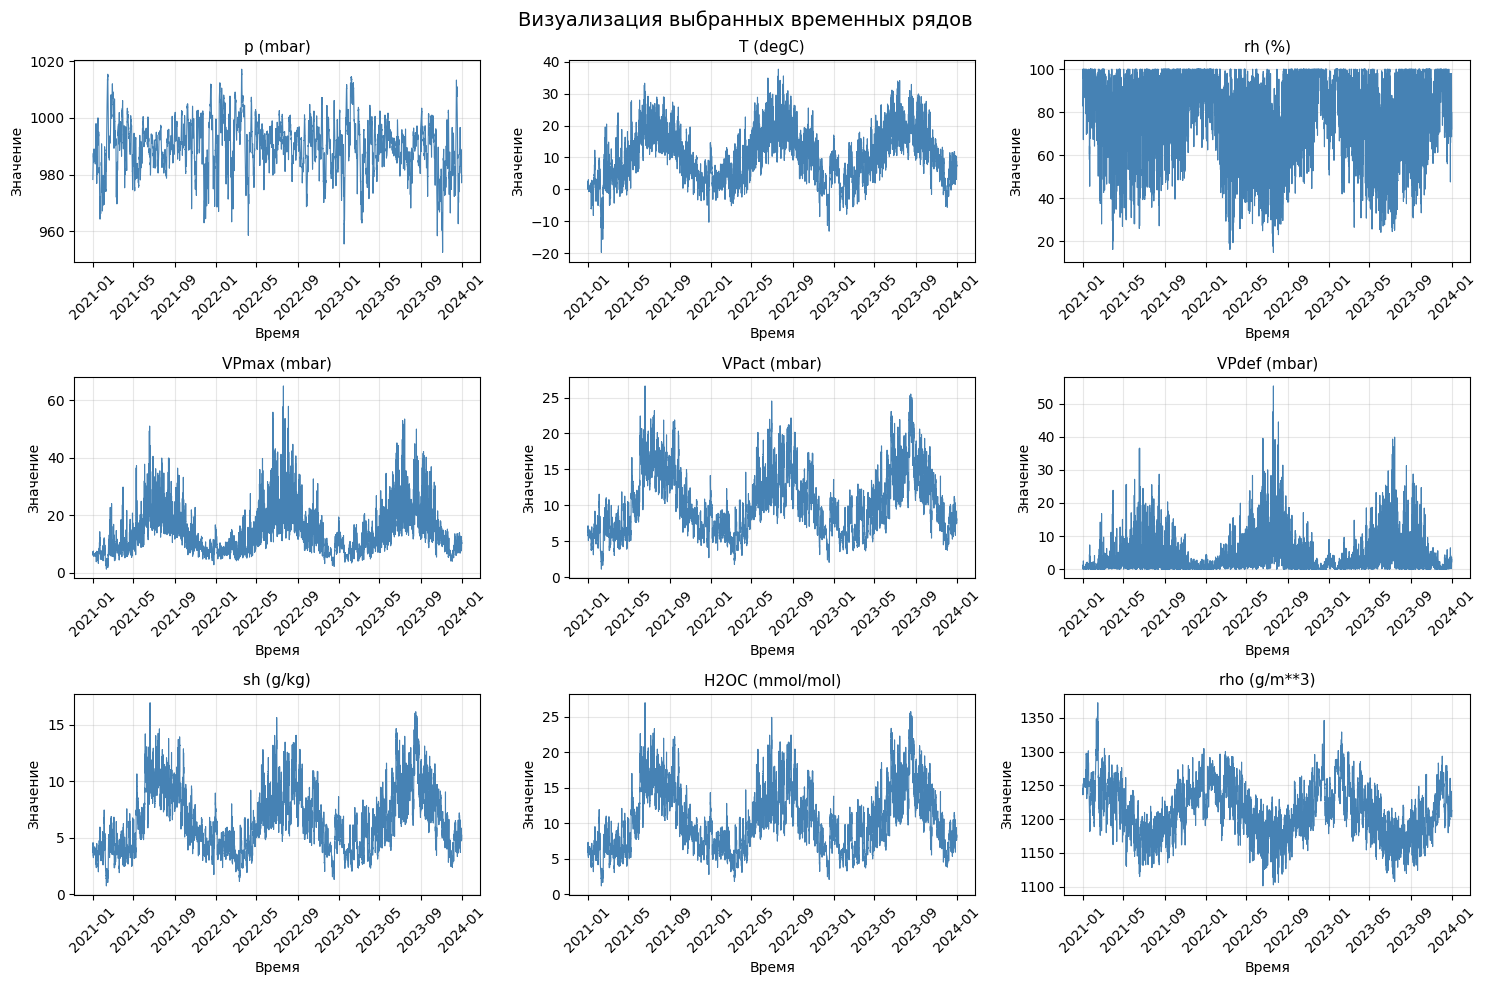

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    axes[i].plot(df_resampled[col], linewidth=0.8, color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Время')
    axes[i].set_ylabel('Значение')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)  

plt.suptitle('Визуализация выбранных временных рядов', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
print("ПРОВЕРКА СТАЦИОНАРНОСТИ")

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'ADF Statistic for {name}: {result[0]:.4f}, p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print(f"Ряд {name} СТАЦИОНАРЕН\n")
    else:
        print(f"Ряд {name} НЕСТАЦИОНАРЕН\n")

for col in df_resampled.columns:
    check_stationarity(df_resampled[col], col)

ПРОВЕРКА СТАЦИОНАРНОСТИ
ADF Statistic for p (mbar): -12.4059, p-value: 0.0000
Ряд p (mbar) СТАЦИОНАРЕН

ADF Statistic for T (degC): -6.3217, p-value: 0.0000
Ряд T (degC) СТАЦИОНАРЕН

ADF Statistic for rh (%): -11.4215, p-value: 0.0000
Ряд rh (%) СТАЦИОНАРЕН

ADF Statistic for VPmax (mbar): -6.8543, p-value: 0.0000
Ряд VPmax (mbar) СТАЦИОНАРЕН

ADF Statistic for VPact (mbar): -7.1451, p-value: 0.0000
Ряд VPact (mbar) СТАЦИОНАРЕН

ADF Statistic for VPdef (mbar): -9.8859, p-value: 0.0000
Ряд VPdef (mbar) СТАЦИОНАРЕН

ADF Statistic for sh (g/kg): -7.2101, p-value: 0.0000
Ряд sh (g/kg) СТАЦИОНАРЕН

ADF Statistic for H2OC (mmol/mol): -7.2077, p-value: 0.0000
Ряд H2OC (mmol/mol) СТАЦИОНАРЕН

ADF Statistic for rho (g/m**3): -7.8223, p-value: 0.0000
Ряд rho (g/m**3) СТАЦИОНАРЕН



АНАЛИЗ ТРЕНДА


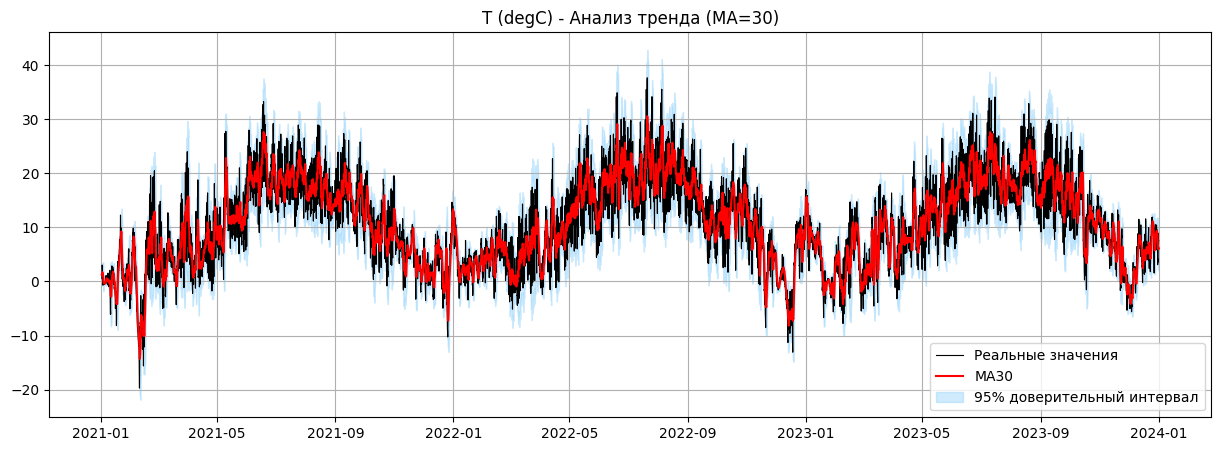

In [ ]:
print("АНАЛИЗ ТРЕНДА")
ts = df_resampled[target_col].dropna()
window = 30
# вычисление скользящего среднего и скользящего стандартного отклонения
rolling_mean = ts.rolling(window=window).mean()
rolling_std = ts.rolling(window=window).std()

plt.figure(figsize=(15, 5))
plt.title(f'{target_col} - Анализ тренда (MA={window})')
plt.plot(ts[window:], label='Реальные значения', color='black', linewidth=0.8)
plt.plot(rolling_mean, label=f'MA{window}', color='red', linewidth=1.5)

lower_bound = rolling_mean - (1.96 * rolling_std)
upper_bound = rolling_mean + (1.96 * rolling_std)
plt.fill_between(x=ts.index, y1=lower_bound, y2=upper_bound, 
                 color='lightskyblue', alpha=0.4, label='95% доверительный интервал')

plt.legend(loc='best')
plt.grid(True)
plt.show()

На графике видно, что температура не растет и не падает со временем, а только циклически меняется по сезонам

АНАЛИЗ СЕЗОННОСТИ


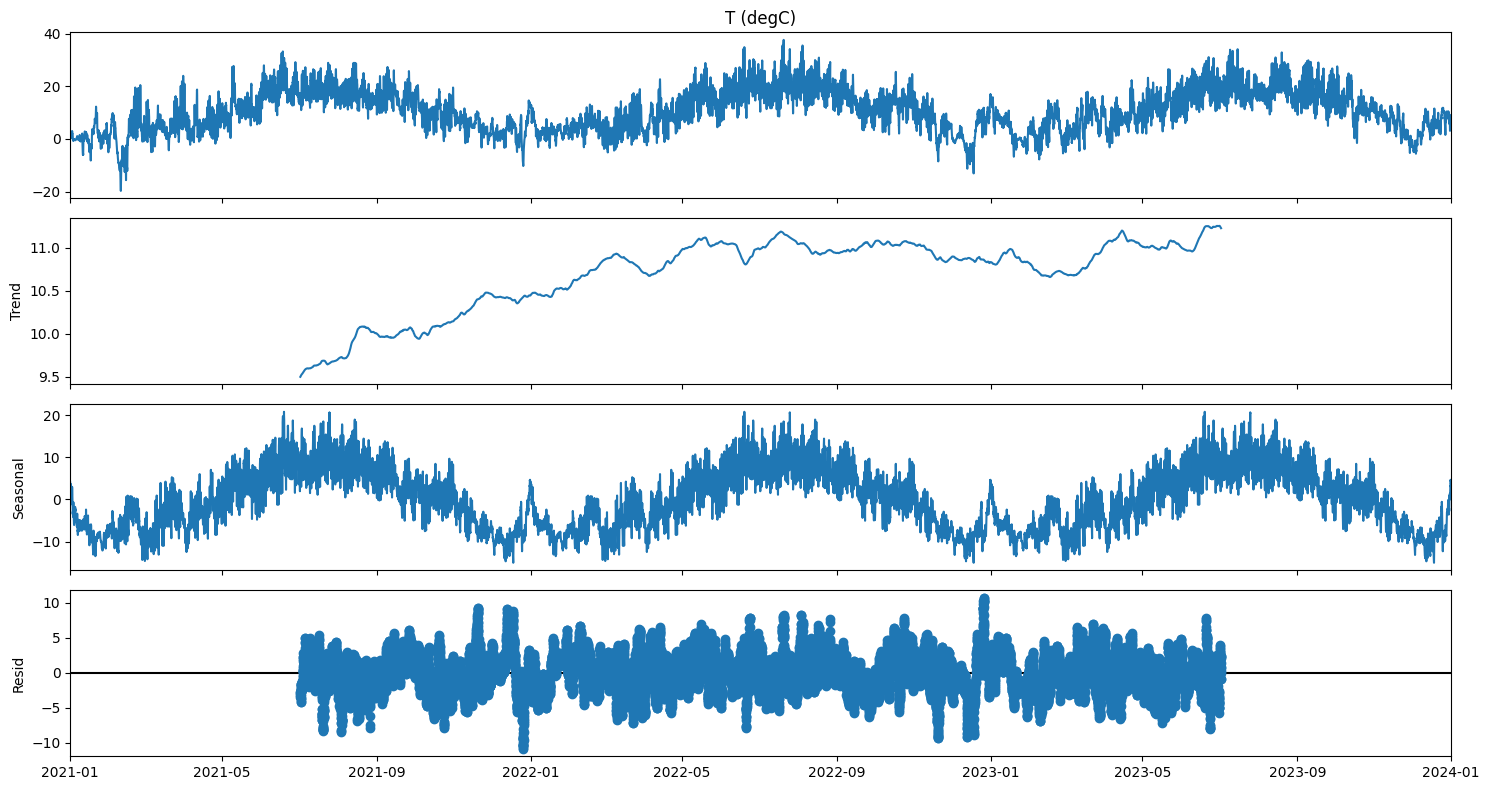

In [ ]:
print("АНАЛИЗ СЕЗОННОСТИ")
decomp_data = df_resampled[target_col].dropna()

if len(decomp_data) > 2 * 24 * 365:  
    period = 24 * 365  
else:
    period = 24  
    
decomposition = seasonal_decompose(decomp_data, model='additive', period=period)

fig = decomposition.plot()
fig.set_size_inches(15, 8)
plt.tight_layout()
plt.show()

Декомпозиция показала, что временной ряд температуры не имеет тренда (стационарен), содержит суточную сезонность, а остатки представляют собой случайный шум без видимых закономерностей.

АВТОКОРРЕЛЯЦИОННЫЙ АНАЛИЗ


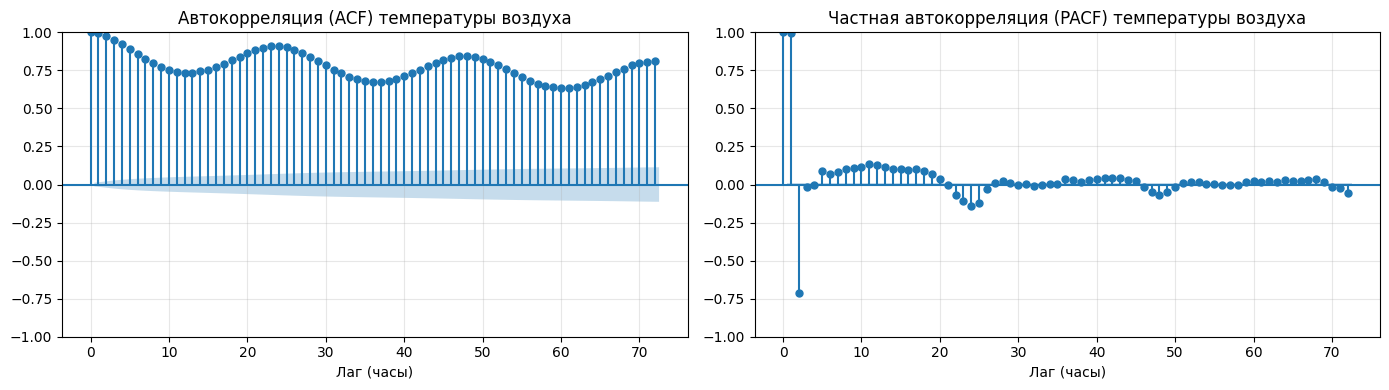

In [28]:
print("АВТОКОРРЕЛЯЦИОННЫЙ АНАЛИЗ")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ts, lags=72, ax=axes[0])
axes[0].set_title('Автокорреляция (ACF) температуры воздуха')
axes[0].set_xlabel('Лаг (часы)')
axes[0].grid(True, alpha=0.3)

plot_pacf(ts, lags=72, ax=axes[1], method='ywm')
axes[1].set_title('Частная автокорреляция (PACF) температуры воздуха')
axes[1].set_xlabel('Лаг (часы)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ACF показывает суточную сезонность, PACF – сильную зависимость только от предыдущего значения.

АНАЛИЗ ВЫБРОСОВ
Q1: 4.38
Q3: 16.41
IQR: 12.03
Выбросов: 40 (0.15%)


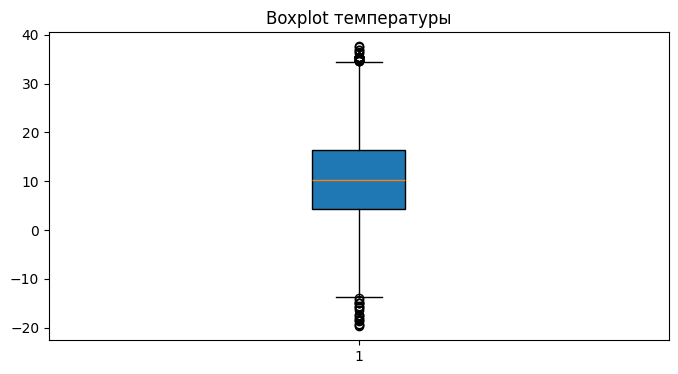

In [ ]:
print("АНАЛИЗ ВЫБРОСОВ")
# Расчет квартилей 
Q1 = df_resampled['T (degC)'].quantile(0.25)
Q3 = df_resampled['T (degC)'].quantile(0.75)
IQR = Q3 - Q1
# Границы для выбросов
lower = Q1 - 1.5 * IQR # нижняя граница (ус)
upper = Q3 + 1.5 * IQR # верхняя граница (ус)

outliers = df_resampled[(df_resampled['T (degC)'] < lower) | (df_resampled['T (degC)'] > upper)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Выбросов: {len(outliers)} ({len(outliers)/len(df_resampled)*100:.2f}%)")

plt.figure(figsize=(8, 4))
plt.boxplot(df_resampled['T (degC)'], patch_artist=True)
plt.title('Boxplot температуры')
plt.show()

Boxplot температуры показывает, что распределение данных симметрично, межквартильный размах составляет 12 градусов, а доля выбросов незначительна (0.15%), поэтому они не требуют специальной обработки.

In [32]:
#ПРЕДОБРАБОТКА
df_work = df_resampled.copy()
target = df_work[target_col]

print(f"Исходных признаков: {len(selected_features)}")
print(f"Строк в df_work: {len(df_work)}")

Исходных признаков: 9
Строк в df_work: 26281


In [ ]:
print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ")

df_feat = df_resampled.copy()
target = df_resampled[target_col]

# МЕТОД 1: LAG FEATURES (температура в прошлом)
for lag in [12, 24, 48, 72]:
    df_feat[f'T_lag_{lag}'] = target.shift(lag)

# МЕТОД 2: ROLLING STATISTICS (показывает общий тренд последних часов)
for window in [12, 24, 48, 72]:
    df_feat[f'T_mean_{window}'] = target.rolling(window).mean()
    df_feat[f'T_std_{window}'] = target.rolling(window).std()

# МЕТОД 3: СТАТИСТИЧЕСКИЕ ПРИЗНАКИ(показывает экстремумы и типичные значения)
for window in [12, 24, 48, 72]:
    df_feat[f'T_min_{window}'] = target.rolling(window).min()
    df_feat[f'T_max_{window}'] = target.rolling(window).max()
    df_feat[f'T_median_{window}'] = target.rolling(window).median()

print(f"Всего признаков до удаления пропусков: {df_feat.shape[1]}")
# ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (предсказываем температуру через 6 часов)
HORIZON = 6  

# Целевая переменная - сдвинутая вперед
df_feat['target_horizon'] = target.shift(-HORIZON)

# Удаляем пропуски 
df_feat = df_feat.dropna()
print(f"После удаления пропусков: {len(df_feat)} строк")

ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ
Всего признаков до удаления пропусков: 33
После удаления пропусков: 26203 строк


In [86]:
# РАЗДЕЛЕНИЕ НА TRAIN/TEST (БЕЗ ПЕРЕМЕШИВАНИЯ)

# Признаки (все колонки, кроме целевой и исходной температуры)
X = df_feat.drop(columns=[target_col, 'target_horizon'])
y = df_feat['target_horizon']

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")
print(f"Признаков: {X_train.shape[1]}")

Train: 20962
Test: 5241
Признаков: 32


In [87]:
print("RANDOM FOREST")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")

RANDOM FOREST
MAE: 2.0386
RMSE: 2.6739
R²: 0.8778


In [ ]:
print("LSTM")

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Масштабирование (Без масштабирования LSTM может не обучиться или обучаться очень долго)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Преобразуем в 3D формат
X_train_s = X_train_s.reshape(X_train_s.shape[0], 1, X_train_s.shape[1])
X_test_s = X_test_s.reshape(X_test_s.shape[0], 1, X_test_s.shape[1])

# LSTM модель
lstm = Sequential([
    LSTM(50, input_shape=(1, X_train_s.shape[2])),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train_s, y_train, epochs=20, batch_size=32, verbose=1)

# Прогноз
y_pred_lstm = lstm.predict(X_test_s).flatten()

mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm = r2_score(y_test, y_pred_lstm)

print(f"MAE: {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"R²: {r2_lstm:.4f}")

LSTM
Epoch 1/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 48.9863
Epoch 2/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.9998
Epoch 3/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.5768
Epoch 4/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.9797
Epoch 5/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.3523
Epoch 6/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.0412
Epoch 7/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8619
Epoch 8/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.7118
Epoch 9/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.6039
Epoch 10/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.5285
Epoch 11/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.4443
Epoch 12/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.4134
Epoch 13/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.3499
Epoch 14/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.2790
Epoch 15/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/st

In [90]:
print("GRU")

from tensorflow.keras.layers import GRU

gru = Sequential([
    GRU(50, input_shape=(1, X_train_s.shape[2])),
    Dense(1)
])
gru.compile(optimizer='adam', loss='mse')
gru.fit(X_train_s, y_train, epochs=20, batch_size=32, verbose=1)

y_pred_gru = gru.predict(X_test_s).flatten()

mae_gru = mean_absolute_error(y_test, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))
r2_gru = r2_score(y_test, y_pred_gru)

print(f"MAE: {mae_gru:.4f}")
print(f"RMSE: {rmse_gru:.4f}")
print(f"R²: {r2_gru:.4f}")

GRU
Epoch 1/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 37.9625
Epoch 2/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.9242
Epoch 3/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.9383
Epoch 4/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.4332
Epoch 5/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.1347
Epoch 6/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.9575
Epoch 7/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8437
Epoch 8/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.7185
Epoch 9/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.6208
Epoch 10/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.5602
Epoch 11/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.5093
Epoch 12/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.4750
Epoch 13/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.4283
Epoch 14/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.3875
Epoch 15/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [92]:
print("СРАВНЕНИЕ МОДЕЛЕЙ")

# Таблица
comparison = pd.DataFrame({
    'Модель': ['Random Forest', 'LSTM', 'GRU'],
    'MAE': [mae_rf, mae_lstm, mae_gru],
    'RMSE': [rmse_rf, rmse_lstm, rmse_gru],
    'R²': [r2_rf, r2_lstm, r2_gru]
})

print(comparison.to_string(index=False))

# Лучшая модель (по R²)
best = comparison.loc[comparison['R²'].idxmax(), 'Модель']
best_r2 = comparison.loc[comparison['R²'].idxmax(), 'R²']
best_mae = comparison.loc[comparison['R²'].idxmax(), 'MAE']

print(f"\nЛУЧШАЯ МОДЕЛЬ: {best}")
print(f"   R² = {best_r2:.4f}")
print(f"   MAE = {best_mae:.4f}")

СРАВНЕНИЕ МОДЕЛЕЙ
       Модель      MAE     RMSE       R²
Random Forest 2.038574 2.673901 0.877805
         LSTM 1.775392 2.328113 0.907366
          GRU 1.782024 2.327691 0.907399

ЛУЧШАЯ МОДЕЛЬ: GRU
   R² = 0.9074
   MAE = 1.7820


GRU и LSTM лучше Random Forest, потому что:
Random Forest смотрит на каждый час отдельно, не видит, что было раньше
LSTM и GRU помнят прошлое и понимают, как температура меняется во времени

Близость результатов LSTM и GRU:
Для прогноза на 6 часов достаточно простой архитектуры GRU
LSTM не показал преимущества, так как задача не требует очень долгой памяти